# NGS variant calling workflow

<div style="background-color: PaleTurquoise; padding: 10px;">
    
This notebook contains a simple SNP calling workflow.

Please run and explore this workflow.

Areas with questions about QC are highlighted in yellow

</div>

## Case

Two exome sequencing samples of a T-Cell Acute Lymphoblastic Leukemia patient. 

One sample (`TLE66_T`) is of tumor, one healthy control sample  (`TLE66_N`)

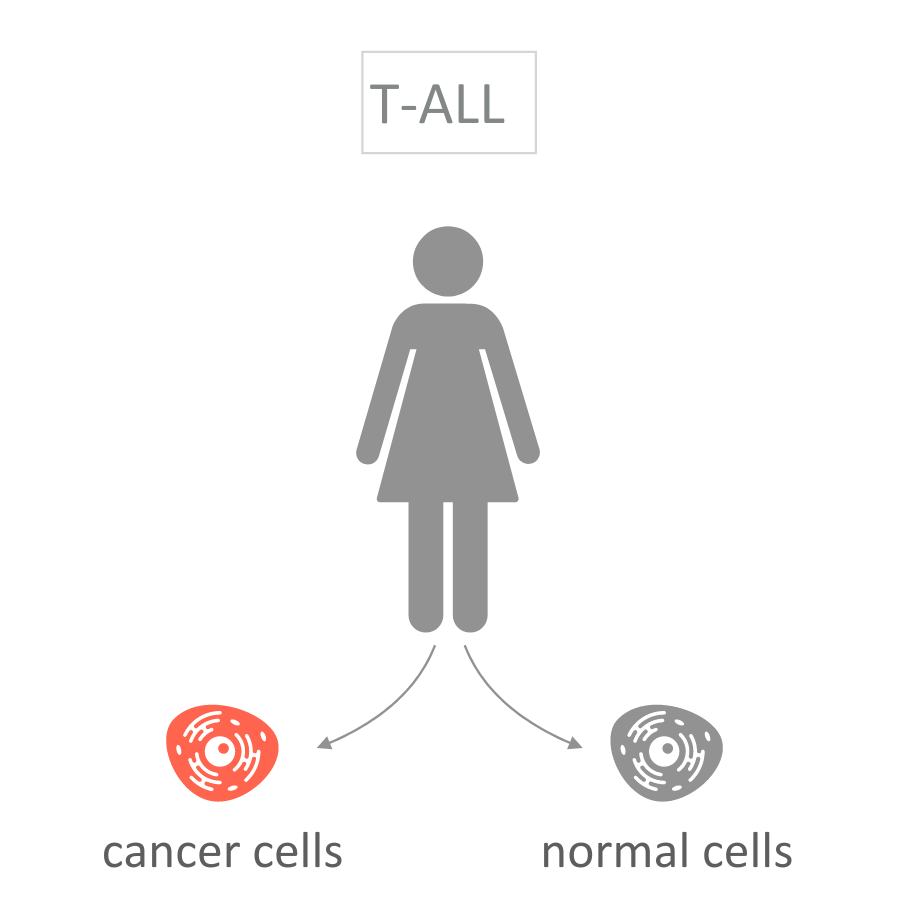

Goal: process the raw fastq, call & annotate SNPs.

We want to ultimately find interesting variants that may be causal to the T-ALL.

## Preparation

In [2]:
echo $VSC_DATA

/data/leuven/381/vsc38158


The cleanest way to work with notebooks is to first create a folder on your server (VSC). For example:

    mkdir $VSC_DATA/variant_calling_manual

- You can do this in the jupyter interface
- Upload your notebook to this folder
- Navigate to this folder from jupyter
- Open the notebook

This ensures you are always working from the correct location. If you did not do this, please shutdown this notebook and do this.

If you do not do this, you are in the wrong folder upon a notebook crash, or when you forget to cd into your workfolder.

In [3]:
# make sure we add our conda environment to the path
# there are also a number of command line tools installed
# You need to do this every time you need to use our conda env.

export PATH=/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/:$PATH

In [4]:
# ensure we are using the correct environment - test with bwa

which bwa

/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/bwa


In [5]:
# create a scratch folder! - Important to check you are working in the correct scratch folder for subsequent workœ
# Make sure you use absolute paths as much as possible - relative paths can give unexpected results.
# image running (`mkdir variant_calling_manual ; cd variant_calling_manual`) twice in a row.

mkdir -p $VSC_SCRATCH/variant_calling_manual
cd $VSC_SCRATCH/variant_calling_manual
pwd
ls

/scratch/leuven/381/vsc38158/variant_calling_manual
annotated_snps.vcf  raw_snps.vcf	 TLE66_N.bam	  TLE66_T.bam
clean_snps.vcf	    snpEff_genes.txt	 TLE66_N.bam.bai  TLE66_T.bam.bai
fastqc_output	    snpEff_summary.html  TLE66_N.fastq	  TLE66_T.fastq


In [6]:
# We will be using the genome sequence & index a few times - 
# So I'll use an environment variable

# Note - we are definitely using hg19 for this course.

# To keep memory requirements in check we're using a truncated database with just chromosome 9
DB=/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa

In [7]:
ls -lh $DB

-rw-rw-r--+ 1 vsc30690 lp_edu_large_omics 135M Jan 24  2014 /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


<div style="background-color: khaki; padding: 10px;">

## Prepare

* What are the version numbers of all tools used in this notebook. Get it from the tools!
 
</div>

In [8]:
#bwa doesn't immedietly show version 
bwa 2>&1 | grep "Version" 
samtools --version | head -1
fastqc --version
bcftools --version | head -1
#same as bwa
vt 2>&1 | grep "vt v" 
# snpEff isn't a standalone application
java -jar ${SNPEFF_JAR} 2>&1 | grep "version" 

Version: 0.7.19-r1273
samtools 1.23
FastQC v0.12.1
bcftools 1.23
    -version      print product version to the error stream and exit
    --version     print product version to the output stream and exit
    -showversion  print product version to the error stream and continue
    --show-version
                  print product version to the output stream and continue


In [9]:
# Create a symlink to VSC_SCRATCH from $VSC_DATA -
# so that you can inspect your data using the jupyter file browser
ln -sf $VSC_SCRATCH $VSC_DATA/scratch 

In [10]:
ln -sf /staging/leuven/stg_00079/teaching/data_manual_snpcall/*.fastq .
ls -l

total 70836
-rw-r----- 1 vsc38158 vsc38158  1775439 Feb 26 14:35 annotated_snps.vcf
-rw-r----- 1 vsc38158 vsc38158   567832 Feb 26 14:34 clean_snps.vcf
drwxr-x--- 3 vsc38158 vsc38158     4096 Feb 26 15:37 fastqc_output
-rw-r----- 1 vsc38158 vsc38158   982232 Feb 26 14:26 raw_snps.vcf
-rw-r----- 1 vsc38158 vsc38158    43281 Feb 26 14:35 snpEff_genes.txt
-rw-r----- 1 vsc38158 vsc38158   230498 Feb 26 14:35 snpEff_summary.html
-rw-r----- 1 vsc38158 vsc38158 36321020 Feb 26 14:17 TLE66_N.bam
-rw-r----- 1 vsc38158 vsc38158    80208 Feb 26 14:17 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38158 vsc38158       68 Mar  5 03:33 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
-rw-r----- 1 vsc38158 vsc38158 32427184 Feb 26 14:17 TLE66_T.bam
-rw-r----- 1 vsc38158 vsc38158    79776 Feb 26 14:17 TLE66_T.bam.bai
lrwxrwxrwx 1 vsc38158 vsc38158       68 Mar  5 03:33 TLE66_T.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_T.fastq


The `sha256` checksums of these files are supposed to be:

    5ad4bb2f5bd5f6e430b7ab2fff0a164255d4e608363104a75142b6c5a032ddf9  TLE66_N.fastq
    cd9d41d1c0b59a4819fa58007ef796c543b1a7346cb11cceb71ad02d9e2b2cfe  TLE66_T.fastq


<div style="background-color: khaki; padding: 10px;">

## Raw data Quality Control

* Do the checksums match?
* Do the raw files look like fastq?
* Do they have a reasonable number of reads?
 
</div>

In [11]:
sha256sum TLE66_N.fastq TLE66_T.fastq
head -8 TLE66_N.fastq
tail -8 TLE66_N.fastq
wc -l TLE66_N.fastq
wc -l TLE66_T.fastq

5ad4bb2f5bd5f6e430b7ab2fff0a164255d4e608363104a75142b6c5a032ddf9  TLE66_N.fastq
cd9d41d1c0b59a4819fa58007ef796c543b1a7346cb11cceb71ad02d9e2b2cfe  TLE66_T.fastq
@1121358
TGAATCTGGGAGGCGGAGGTTGCAGTGAGAGTGAGGCGAGATCTCGCCATTGCACTCCAGCCGGGGTGACAAGAG
+
<D<?><DIBB??BF;@;AB@CHG<A?F<@>@;F>>6?8??@@BD,;FF=?DIBD?F;EDAGE8BBC9G?FEBB>@
@1121358
AGCCTCAAACTCCTGGGCTCAAGGGATCCTCACTTCTTGACCTCCCAAAGCGTCATAGGCTTAAGGCACTACAGC
+
A:EFFACACFE?FCG5CG9>C@@B@<@=@FACFEE<F9C>E6FAC+7>:AF=B=A?>B;CG>:<A:<=<B;:0=;
@3701622
CTCCCAGGCTTATCAGGACAAGGAAATTCCCGCCTAATAAATGTTGGTCAGATGGGTTGTCTGCTCTCAAACCCT
+
CEDGGDDEGEEBBECFFBGDDFFADECDFHH?HGGAEBBDD@ICFIDBCEBBBHE<@@ICBHI6H@G0ACD<9GH
@FCD0CAEABXX:4:1107:9293:169642
CTCCCAGGCTTATCAGGACAAGGAAATTCCCGCCTAATAAATGTTGGTCAGATGGGTTGTCTGCTCTCAAACCCT
+
CFEGIED@IGFCBFEFFAIFDEDAFEBFFII@HJEBFDDEE>L@FKGDEEFCBJFEDGCE7GKIICGD>B7<@'D
2162496 TLE66_N.fastq
1911552 TLE66_T.fastq


In [12]:
file -L *

annotated_snps.vcf:  Variant Call Format (VCF) version 4.2, ASCII text, with very long lines
clean_snps.vcf:      Variant Call Format (VCF) version 4.2, ASCII text, with very long lines
fastqc_output:       directory
raw_snps.vcf:        Variant Call Format (VCF) version 4.2, ASCII text, with very long lines
snpEff_genes.txt:    ASCII text, with very long lines
snpEff_summary.html: HTML document, ASCII text, with very long lines
TLE66_N.bam:         Blocked GNU Zip Format (BGZF; gzip compatible), block length 231
TLE66_N.bam.bai:     SAMtools BAI (BAM indexing format), with 1 reference sequences
TLE66_N.fastq:       ASCII text
TLE66_T.bam:         Blocked GNU Zip Format (BGZF; gzip compatible), block length 223
TLE66_T.bam.bai:     SAMtools BAI (BAM indexing format), with 1 reference sequences
TLE66_T.fastq:       ASCII text


In [13]:
# you can get help using
fastqc --help


            FastQC - A high throughput sequence QC analysis tool

SYNOPSIS

	fastqc seqfile1 seqfile2 .. seqfileN

    fastqc [-o output dir] [--(no)extract] [-f fastq|bam|sam] 
           [-c contaminant file] seqfile1 .. seqfileN

DESCRIPTION

    FastQC reads a set of sequence files and produces from each one a quality
    control report consisting of a number of different modules, each one of 
    which will help to identify a different potential type of problem in your
    data.
    
    If no files to process are specified on the command line then the program
    will start as an interactive graphical application.  If files are provided
    on the command line then the program will run with no user interaction
    required.  In this mode it is suitable for inclusion into a standardised
    analysis pipeline.
    
    The options for the program as as follows:
    
    -h --help       Print this help file and exit
    
    -v --version    Print the version of the program and exit

In [14]:
# Run fastqc - could take a minute or two
mkdir -p fastqc_output
fastqc *.fastq -o fastqc_output

null
null
Started analysis of TLE66_N.fastq
Approx 5% complete for TLE66_N.fastq
Approx 10% complete for TLE66_N.fastq
Approx 15% complete for TLE66_N.fastq
Approx 20% complete for TLE66_N.fastq
Approx 25% complete for TLE66_N.fastq
Approx 30% complete for TLE66_N.fastq
Approx 35% complete for TLE66_N.fastq
Approx 40% complete for TLE66_N.fastq
Approx 45% complete for TLE66_N.fastq
Approx 50% complete for TLE66_N.fastq
Approx 55% complete for TLE66_N.fastq
Approx 60% complete for TLE66_N.fastq
Approx 65% complete for TLE66_N.fastq
Approx 70% complete for TLE66_N.fastq
Approx 75% complete for TLE66_N.fastq
Approx 80% complete for TLE66_N.fastq
Approx 85% complete for TLE66_N.fastq
Approx 90% complete for TLE66_N.fastq
Approx 95% complete for TLE66_N.fastq
Analysis complete for TLE66_N.fastq
Started analysis of TLE66_T.fastq
Approx 5% complete for TLE66_T.fastq
Approx 10% complete for TLE66_T.fastq
Approx 15% complete for TLE66_T.fastq
Approx 20% complete for TLE66_T.fastq
Approx 25% com

Back in your jupyter browser you can see the html & zip outputs

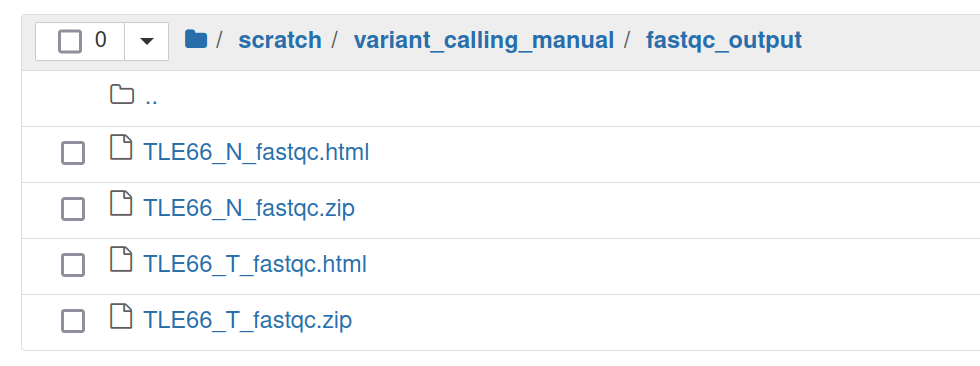


<div style="background-color: khaki; padding: 10px;">

## Fastq data Quality Control

* Is the quality ok?
* How is the quality score encoded? Do you need to take this into account?
 
</div>

In [15]:
#they qulaity is v good w phred scores sitting in the range of 35-36 this is less than 0.025% chance of a wrong base call per base 
# Sanger / Illumina 1.9 this is the newer standardized vefrsion so doesn't need to be taken into account

## Align the reads

We will be using `bwa mem`. Get help by running without arguments

In [16]:
bwa mem || true


Usage: bwa mem [options] <idxbase> <in1.fq> [in2.fq]

Algorithm options:

       -t INT        number of threads [1]
       -k INT        minimum seed length [19]
       -w INT        band width for banded alignment [100]
       -d INT        off-diagonal X-dropoff [100]
       -r FLOAT      look for internal seeds inside a seed longer than {-k} * FLOAT [1.5]
       -y INT        seed occurrence for the 3rd round seeding [20]
       -c INT        skip seeds with more than INT occurrences [500]
       -D FLOAT      drop chains shorter than FLOAT fraction of the longest overlapping chain [0.50]
       -W INT        discard a chain if seeded bases shorter than INT [0]
       -m INT        perform at most INT rounds of mate rescues for each read [50]
       -S            skip mate rescue
       -P            skip pairing; mate rescue performed unless -S also in use

Scoring options:

       -A INT        score for a sequence match, which scales options -TdBOELU unless overridden [1]
     

In [17]:
echo ${DB}

/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


In [18]:
bwa mem ${DB} TLE66_N.fastq | samtools sort -o TLE66_N.bam -

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.079 CPU sec, 3.034 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.518 CPU sec, 3.447 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.477 CPU sec, 3.407 real sec
[M::process] read 7288 sequences (546600 bp)...
[M::mem_process_seqs] Processed 133334 reads in 4.306 CPU sec, 4.278 real sec
[M::mem_process_seqs] Processed 7288 reads in 0.293 CPU sec, 0.259 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.fastq
[main] Real time: 15.551 sec; CPU: 14.915 sec


In [19]:
bwa mem ${DB} TLE66_T.fastq | samtools sort - > TLE66_T.bam

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.118 CPU sec, 3.099 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.439 CPU sec, 3.370 real sec
[M::process] read 77886 sequences (5841450 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.597 CPU sec, 3.549 real sec
[M::mem_process_seqs] Processed 77886 reads in 2.791 CPU sec, 2.761 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_T.fastq
[main] Real time: 12.987 sec; CPU: 13.137 sec


In [20]:
# create indici
samtools index TLE66_N.bam
samtools index TLE66_T.bam

In [21]:
pwd
ls -l

/scratch/leuven/381/vsc38158/variant_calling_manual
total 70836
-rw-r----- 1 vsc38158 vsc38158  1775439 Feb 26 14:35 annotated_snps.vcf
-rw-r----- 1 vsc38158 vsc38158   567832 Feb 26 14:34 clean_snps.vcf
drwxr-x--- 3 vsc38158 vsc38158     4096 Feb 26 15:37 fastqc_output
-rw-r----- 1 vsc38158 vsc38158   982232 Feb 26 14:26 raw_snps.vcf
-rw-r----- 1 vsc38158 vsc38158    43281 Feb 26 14:35 snpEff_genes.txt
-rw-r----- 1 vsc38158 vsc38158   230498 Feb 26 14:35 snpEff_summary.html
-rw-r----- 1 vsc38158 vsc38158 36321020 Mar  5 03:33 TLE66_N.bam
-rw-r----- 1 vsc38158 vsc38158    80208 Mar  5 03:33 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38158 vsc38158       68 Mar  5 03:33 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
-rw-r----- 1 vsc38158 vsc38158 32427184 Mar  5 03:33 TLE66_T.bam
-rw-r----- 1 vsc38158 vsc38158    79776 Mar  5 03:33 TLE66_T.bam.bai
lrwxrwxrwx 1 vsc38158 vsc38158       68 Mar  5 03:33 TLE66_T.fastq -> /staging/leuven/stg_00079/teaching/data_man

<div style="background-color: khaki; padding: 10px;">

## BAM  Quality control

* Did all tools finish without error?
* Is the header correct? (Use `samtools view -H`)
* Do the files look like BAM? (Use `samtools view ... | head`)
* To which chromosomes to the reads map? (Use `samtools idxstats`) What do you expect? 
* How many & what percentage of the reads map properly? (Use `samtools flagstat`)
* Download the bam & bai files to disk & visualize in [IGV](https://igv.org/app/). Copy/paste a screenshot.

</div>

In [40]:
samtools view -H TLE66_N.bam | head -20
#header looks correct
samtools view TLE66_N.bam | head -3
#file looks like BAM 
samtools idxstats TLE66_N.bam
#chr 9
#faster than reading teh whole bam file
samtools flagstat TLE66_N.bam
#540563 + 0 mapped (99.98%)


540661 + 0 in total (QC-passed reads + QC-failed reads)
540624 + 0 primary
0 + 0 secondary
37 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
540563 + 0 mapped (99.98% : N/A)
540526 + 0 primary mapped (99.98% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


## SNP Calling

Using bcftools

In [23]:
#get help
bcftools mpileup || true


Usage: bcftools mpileup [options] in1.bam [in2.bam [...]]

Input options:
  -6, --illumina1.3+      Quality is in the Illumina-1.3+ encoding
  -A, --count-orphans     Include anomalous read pairs, with flag PAIRED but not PROPER_PAIR set
  -b, --bam-list FILE     List of input BAM filenames, one per line
  -B, --no-BAQ            Disable BAQ (per-Base Alignment Quality)
  -C, --adjust-MQ INT     Adjust mapping quality [0]
  -D, --full-BAQ          Apply BAQ everywhere, not just in problematic regions
  -d, --max-depth INT     Max raw per-file depth; avoids excessive memory usage [250]
  -E, --redo-BAQ          Recalculate BAQ on the fly, ignore existing BQs
  -f, --fasta-ref FILE    Faidx indexed reference sequence file
      --no-reference      Do not require fasta reference file
  -G, --read-groups FILE  Select or exclude read groups listed in the file
  -q, --min-MQ INT        Skip alignments with mapQ smaller than INT [0]
  -Q, --min-BQ INT        Skip bases with baseQ/BAQ smaller

In [24]:
bcftools mpileup -Ou -f ${DB} TLE66_N.bam TLE66_T.bam \
    | bcftools call -mv -Ov -o raw_snps.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 2 samples in 2 input files
[mpileup] maximum number of reads per input file set to -d 250


In [25]:
ls

annotated_snps.vcf  raw_snps.vcf	 TLE66_N.bam	  TLE66_T.bam
clean_snps.vcf	    snpEff_genes.txt	 TLE66_N.bam.bai  TLE66_T.bam.bai
fastqc_output	    snpEff_summary.html  TLE66_N.fastq	  TLE66_T.fastq


In [26]:
head raw_snps.vcf

##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23+htslib-1.23
##bcftoolsCommand=mpileup -Ou -f /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.bam TLE66_T.bam
##reference=file:///staging/leuven/stg_00079/teaching/hg38_9/chr9.fa
##contig=<ID=chr9,length=138394717>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">


In [27]:
grep  '^#' raw_snps.vcf | tail

##FORMAT=<ID=PL,Number=G,Type=Integer,Description="List of Phred-scaled genotype likelihoods">
##FORMAT=<ID=AD,Number=R,Type=Integer,Description="Allelic depths (high-quality bases)">
##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">
##INFO=<ID=AC,Number=A,Type=Integer,Description="Allele count in genotypes for each ALT allele, in the same order as listed">
##INFO=<ID=AN,Number=1,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=DP4,Number=4,Type=Integer,Description="Number of high-quality ref-forward , ref-reverse, alt-forward and alt-reverse bases">
##INFO=<ID=MQ,Number=1,Type=Integer,Description="Average mapping quality">
##bcftools_callVersion=1.23+htslib-1.23
##bcftools_callCommand=call -mv -Ov -o raw_snps.vcf; Date=Thu Mar  5 03:34:00 2026
#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	TLE66_N.bam	TLE66_T.bam


In [28]:
grep -v '^#' raw_snps.vcf | head -5

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082813	.	C	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082814	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	35641185	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./.:0,0,0:0,0


<div style="background-color: khaki; padding: 10px;">

## VCF/bcftools Quality control

* Did all tools finish without error?
* Is the file structure correct? (no lines, start, end, header, etc)
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* Visualize the above SNP in IGV, copy/paste a screenshot.

</div>

In [44]:
#file structure 
grep '^#' raw_snps.vcf | tail -3
grep -v '^#' raw_snps.vcf | head -3
#high quality SNP 
grep -v '^#' raw_snps.vcf | awk '$6 > 100' | head -5
#variant difference 
grep -v '^#' raw_snps.vcf | awk '$10 ~ /^0/ && $11 ~ /^1/' | head -5

chr9	127770299	.	G	T	12.9732	.	DP=5;VDB=0.74;SGB=0.00473136;RPBZ=0;MQBZ=0;MQSBZ=0;BQBZ=-1.73205;SCBZ=0;MQ0F=0;AC=2;AN=4;DP4=2,1,1,1;MQ=60	GT:PL:AD	0/0:0,9,98:3,0	1/1:49,6,0:0,2
chr9	127786310	.	GCCCCCCCC	GCCCCCCCCC	143.979	.	INDEL;IDV=5;IMF=0.714286;DP=12;VDB=0.201452;SGB=-1.03866;RPBZ=-0.509525;MQBZ=0;MQSBZ=0;BQBZ=-1.66598;SCBZ=0;MQ0F=0;AC=3;AN=4;DP4=0,3,0,9;MQ=60	GT:PL:AD	0/1:68,0,14:2,3	1/1:109,10,0:1,6
chr9	127817814	.	T	C	38.7974	.	DP=3;VDB=0.56;SGB=0.0985265;RPBZ=-1.22474;MQBZ=0;MQSBZ=0;BQBZ=0.707107;SCBZ=0;MQ0F=0;AC=3;AN=4;DP4=0,1,1,1;MQ=60	GT:PL:AD	0/1:0,3,35:1,0	1/1:73,6,0:0,2
chr9	127839297	.	C	T	26.7041	.	DP=3;VDB=0.1;SGB=-0.759771;RPBZ=1.22474;MQBZ=0;MQSBZ=0;BQBZ=-1.22474;SCBZ=0;MQ0F=0;AC=3;AN=4;DP4=1,0,0,2;MQ=60	GT:PL:AD	0/1:25,0,34:1,1	1/1:34,3,0:0,1
chr9	127873579	.	G	A	41.7917	.	DP=3;VDB=0.6;SGB=0.0985265;RPBZ=-1.22474;MQBZ=0;MQSBZ=0;BQBZ=-1.22474;SCBZ=0;MQ0F=0;AC=3;AN=4;DP4=0,1,1,1;MQ=60	GT:PL:AD	0/1:0,3,40:1,0	1/1:76,6,0:0,2


In [29]:
grep -v '#' raw_snps.vcf | head -2

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2


Not all SNPs are equaly convincing

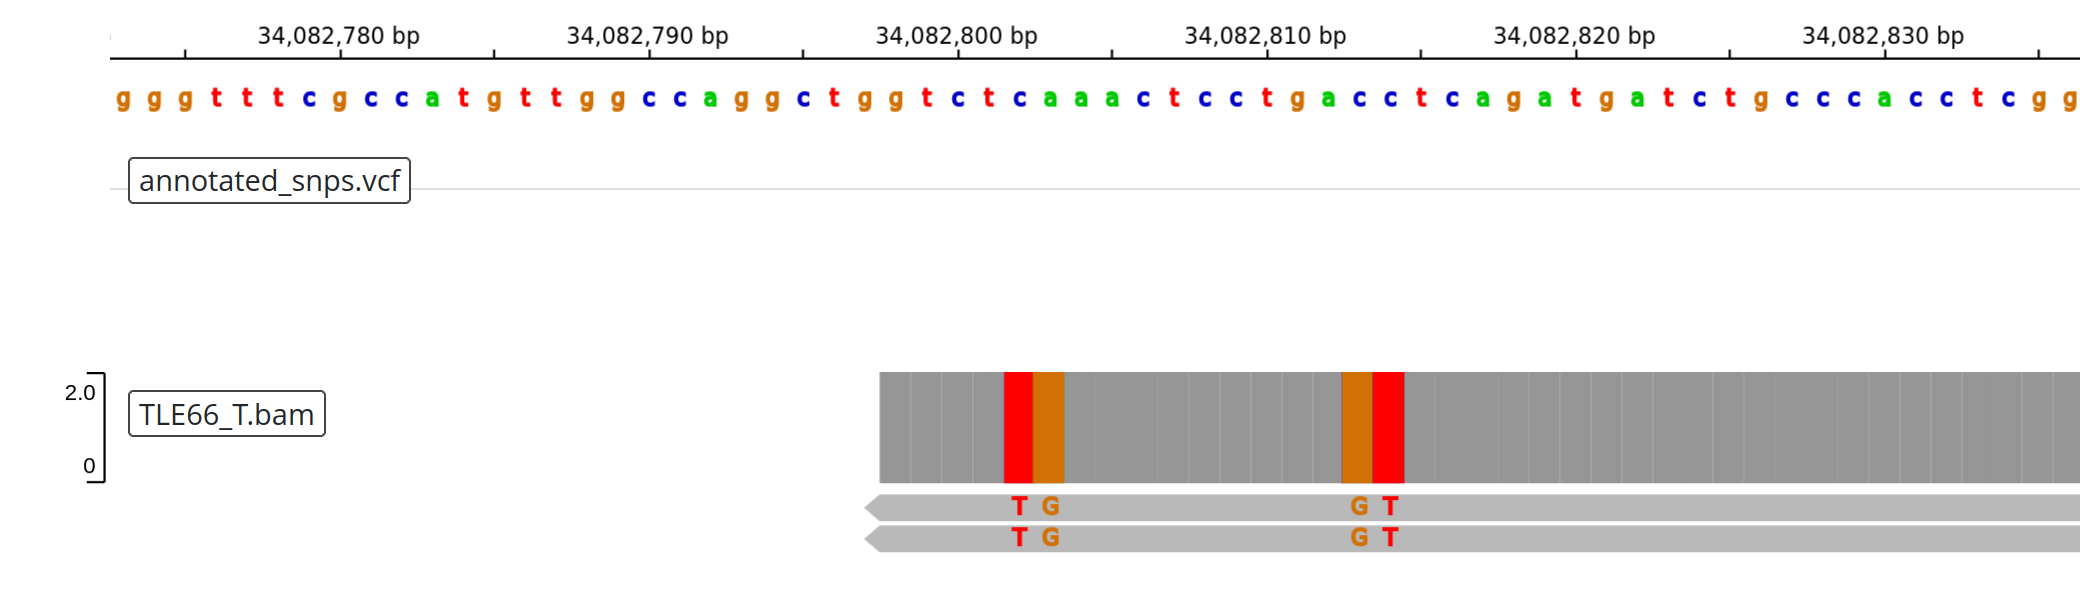

## SNP filtering & cleaning using `vt`

This is a VCF preprocessing pipeline that cleans up raw SNP calls before any downstream analysis. Each step fixes a specific class of problem:

* `vt decompose` splits multi-allelic variants (where multiple alternate alleles are listed on a single line) into separate biallelic records. Most tools downstream expect one variant per line, and PRS methods in particular are built around biallelic SNPs.
* `vt normalize -n -r $DB` left-aligns and normalizes indels against the reference genome. The same variant can be represented in multiple valid ways in VCF format — normalization ensures you have one canonical representation, which is critical when matching variants across datasets (e.g., GWAS summary statistics vs. your genotype calls).
* `vt uniq` removes exact duplicate records that may have arisen after decomposition and normalization — two originally different representations that are now identical.
* `vt view -f "QUAL>20"` filters out low-confidence variant calls. QUAL<20 corresponds roughly to less than 99% confidence that the variant is real, so you're dropping the noisiest calls.


In [30]:
cat raw_snps.vcf \
    | vt decompose - \
    | vt normalize -n -r $DB - \
    | vt uniq - \
    | vt view -f "QUAL>20" -h - \
    > clean_snps.vcf

decompose v0.5

options:     input VCF file        -
         [s] smart decomposition   false (experimental)
         [o] output VCF file       -

normalize v0.5

options:     input VCF file                                  -
         [o] output VCF file                                 -
         [w] sorting window size                             10000
         [n] no fail on reference inconsistency for non SNPs true
         [q] quiet                                           false
         [d] debug                                           false
         [r] reference FASTA file                            /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa

uniq v0.57

options:     input VCF file        -
         [o] output VCF file       -

stats: no. variants                 : 6661
       no. biallelic variants       : 6659
       no. multiallelic variants    : 2

       no. additional biallelics    : 2
       total no. of biallelics      : 6663

Time elapsed: 0.02s


stats: biall


<div style="background-color: khaki; padding: 10px;">

## Quality control

* Did all tools finish without error?
* Is the file structure correct? (no lines, start, end, header, etc)
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* Visualize the above SNP in IGV, copy/paste a screenshot.

</div>



In [47]:
# number of SNP's filtered
grep -v '^#' raw_snps.vcf | wc -l
grep -v '^#' clean_snps.vcf | wc -l
#nearly half were noice
#high qulaity SNP
grep -v '^#' clean_snps.vcf | awk '$6 > 200' | head -5
# heterozygot in both normal and tumor -> patient was born w it (germline variant)
# clean variants that are different
grep -v '^#' clean_snps.vcf | awk '$10 ~ /^0/ && $11 ~ /^1/' | head -5

6661
3499
bash: 3grep: command not found
chr9	127786310	.	G	GC	143.979	.	INDEL;IDV=5;IMF=0.714286;DP=12;VDB=0.201452;SGB=-1.03866;RPBZ=-0.509525;MQBZ=0;MQSBZ=0;BQBZ=-1.66598;SCBZ=0;MQ0F=0;AC=3;AN=4;DP4=0,3,0,9;MQ=60;OLD_VARIANT=chr9:127786310:GCCCCCCCC/GCCCCCCCCC	GT:PL:AD	0/1:68,0,14:2,3	1/1:109,10,0:1,6
chr9	127817814	.	T	C	38.7974	.	DP=3;VDB=0.56;SGB=0.0985265;RPBZ=-1.22474;MQBZ=0;MQSBZ=0;BQBZ=0.707107;SCBZ=0;MQ0F=0;AC=3;AN=4;DP4=0,1,1,1;MQ=60	GT:PL:AD	0/1:0,3,35:1,0	1/1:73,6,0:0,2
chr9	127839297	.	C	T	26.7041	.	DP=3;VDB=0.1;SGB=-0.759771;RPBZ=1.22474;MQBZ=0;MQSBZ=0;BQBZ=-1.22474;SCBZ=0;MQ0F=0;AC=3;AN=4;DP4=1,0,0,2;MQ=60	GT:PL:AD	0/1:25,0,34:1,1	1/1:34,3,0:0,1
chr9	127873579	.	G	A	41.7917	.	DP=3;VDB=0.6;SGB=0.0985265;RPBZ=-1.22474;MQBZ=0;MQSBZ=0;BQBZ=-1.22474;SCBZ=0;MQ0F=0;AC=3;AN=4;DP4=0,1,1,1;MQ=60	GT:PL:AD	0/1:0,3,40:1,0	1/1:76,6,0:0,2
chr9	128057612	.	G	T	25.5532	.	DP=4;VDB=0.8;SGB=0.00473136;RPBZ=0.774597;MQBZ=0;MQSBZ=0;BQBZ=-1.54919;SCBZ=0;MQ0F=0;AC=2;AN=4;DP4=1,1,1,1;MQ=60	GT:

## Snp Annotation using SnpEff

In [31]:
# get help using:
snpEff || true

Error        :	Missing genomer_version parameter
Command line :	SnpEff  

snpEff version SnpEff 5.4a (build 2025-11-25 12:22), by Pablo Cingolani
Usage: snpEff [ann] [options] genome_version [input_file]


	variants_file                   : Default is STDIN



Options:
	-chr <string>                   : Prepend 'string' to chromosome name (e.g. 'chr1' instead of '1'). Only on TXT output.
	-classic                        : Use old style annotations instead of Sequence Ontology and Hgvs.
	-csvStats <file>                : Create CSV summary file.
	-download                       : Download reference genome if not available. Default: true
	-i <format>                     : Input format [ vcf, bed ]. Default: VCF.
	-fileList                       : Input actually contains a list of files to process.
	-o <format>                     : Output format [ vcf, gatk, bed, bedAnn ]. Default: VCF.
	-s , -stats, -htmlStats         : Create HTML summary file.  Default is 'snpEff_summary.html'
	-noSta

In [32]:
# sorry this is ugly - but to run snpEff - we need more memory
# I'm sure there is a more elegant way - but I could not find it..

SNPEFF_JAR="/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/share/snpeff-5.4.0a-0/snpEff.jar"

java -Xmx3400m -jar ${SNPEFF_JAR} eff hg19 -dataDir /staging/leuven/stg_00079/teaching/snpeff_db \
        clean_snps.vcf > annotated_snps.vcf



NEW VERSION!
	There is a new SnpEff version available: 
		Version      : 5.4C
		Release date : 2026-02-23
		Download URL : https://snpeff-public.s3.amazonaws.com/versions/snpEff_latest_core.zip



<div style="background-color: khaki; padding: 10px;">

## snpEff Quality control

* Do you have annotations in the records? Show one HIGH impact one? 
* Can you think of other (simple) controls for a snpEff annotated vcf file?

</div>


In [50]:
#grep -v '^#' annotated_snps.vcf | head -2
#these are mostly low quality 
grep -v '^#' annotated_snps.vcf | grep 'HIGH' | head -3
#other simple controls include: how many of each qualty variant there is/ checking if cancer genes are effected 

chr9	127912188	.	G	GC	208.644	.	INDEL;IDV=8;IMF=0.666667;DP=21;VDB=0.559446;SGB=-5.64361;RPBZ=0.0711362;MQBZ=0;BQBZ=-1.64721;SCBZ=0.866025;MQ0F=0;AC=2;AN=4;DP4=8,1,11,1;MQ=60;OLD_VARIANT=chr9:127912188:GCCCC/GCCCCC;ANN=GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_001123355.1|protein_coding|8/8|c.792_793insG|p.Asn265fs|1013/4350|792/1029|264/342||,GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_002721.5|protein_coding|7/7|c.681_682insG|p.Asn228fs|766/4103|681/918|227/305||,GC|frameshift_variant|HIGH|PPP6C|PPP6C|transcript|NM_001123369.1|protein_coding|6/6|c.615_616insG|p.Asn206fs|836/4173|615/852|205/283||;LOF=(PPP6C|PPP6C|3|1.00)	GT:PL:AD	0/1:159,0,75:4,8	0/1:83,0,75:5,4
chr9	131337086	.	CAG	C	205.959	.	INDEL;IDV=4;IMF=0.666667;DP=11;VDB=0.537869;SGB=-3.79454;RPBZ=0.914953;MQBZ=0;MQSBZ=0;SCBZ=-1.09545;MQ0F=0;AC=2;AN=4;DP4=2,3,2,4;MQ=60;OLD_VARIANT=chr9:131337086:CAGAGAG/CAGAG;ANN=C|frameshift_variant|HIGH|SPTAN1|SPTAN1|transcript|NM_001363759.2|protein_coding|4/58|c.497_49